In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np   

sns.set_theme(style="whitegrid", context="talk")

project_dir = Path("..").resolve()
data_path = project_dir / "data" / "clean" / "master_dataset.csv"
output_dir = project_dir / "output"
output_dir.mkdir(parents=True, exist_ok=True)


In [2]:
df = pd.read_csv(data_path)

df.head()

,Date,State,GDP ($ million),Unemployment rate (%),Housing Supply,International Student Enrolments,Population,Rental
0,2019-Q1,NSW,602960,5.0,3191.0,240549.0,8032991.0,482.0
1,2019-Q1,VIC,602960,5.0,2662.0,210652.0,6518716.0,388.0
2,2019-Q2,NSW,604702,5.2,3207.0,270968.0,8046748.0,482.0
3,2019-Q2,VIC,604702,5.2,2677.0,231146.0,6537305.0,388.0
4,2019-Q3,NSW,608205,5.3,3221.0,333696.0,8071350.0,480.0


# 1. Data Overview

## 1.1 Checking Data Types

In [3]:
df.dtypes

Date                                    str
State                                   str
GDP ($ million)                       int64
Unemployment rate (%)               float64
Housing Supply                      float64
International Student Enrolments    float64
Population                          float64
Rental                              float64
dtype: object

## 1.2 Fixing Date Type

In [4]:
df["Quarter"] = pd.PeriodIndex(df["Date"], freq="Q")
df = df.sort_values(["State", "Quarter"]).reset_index(drop=True)

df[["Date", "Quarter", "State"]].head()

,Date,Quarter,State
0,2019-Q1,2019Q1,NSW
1,2019-Q2,2019Q2,NSW
2,2019-Q3,2019Q3,NSW
3,2019-Q4,2019Q4,NSW
4,2020-Q1,2020Q1,NSW


# 2. Descriptive Analysis

## 2.1 Descriptive Statistics

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,48,24,2019-Q1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,48,2,NSW,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GDP ($ million),48.0,NaN,NaN,NaN,636772.083333,31074.339692,569302.0,610245.0,642134.0,666597.5,676456.0
Unemployment rate (%),48.0,NaN,NaN,NaN,4.7,1.082157,3.5,3.875,4.4,5.2,7.0
Housing Supply,48.0,NaN,NaN,NaN,3083.375,283.208714,2662.0,2824.5,3079.5,3359.25,3484.0
International Student Enrolments,48.0,NaN,NaN,NaN,261178.729167,60280.578969,146795.0,216581.75,260766.5,293363.75,415483.0
Population,48.0,NaN,NaN,NaN,7457177.25,794035.653988,6518716.0,6615185.5,7519493.5,8126093.5,8536892.0
Rental,48.0,NaN,NaN,NaN,465.479167,71.915728,380.0,392.25,470.0,493.25,647.0
Quarter,48,24,2019Q1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Descriptive statistics show that variables such as GDP and population are measured on a much larger scale compared to rental prices and unemployment rates, which may affect visualisation and interpretation in later analysis. Rental prices exhibit moderate variation, ranging from 380 to 647, suggesting sufficient variability for meaningful analysis. International student enrolments display substantial dispersion, indicating notable changes over time, while unemployment rates are relatively more stable across the sample period. Overall, the variables demonstrate adequate variation for empirical analysis, although differences in scale and dispersion should be considered when interpreting relationships between variables.

## 2.2 Skewness of Variables

In [6]:
df.skew(numeric_only=True)

GDP ($ million)                    -0.367889
Unemployment rate (%)               0.860474
Housing Supply                     -0.012824
International Student Enrolments    0.480905
Population                          0.013530
Rental                              0.789653
dtype: float64

Most variables are approximately symmetric or moderately skewed. Rental prices and unemployment rates exhibit moderate positive skewness, suggesting a slight concentration of observations at lower values with a longer right tail. International student enrolments also show some degree of right skewness, while GDP is slightly left-skewed. In contrast, housing supply and population appear approximately symmetric. These distributions suggest that while extreme values may be present, the overall data structure remains suitable for analysis without requiring major transformations.

## 2.3 Correlation Matrix

In [7]:
corr_matrix = df[[
    "Rental",
    "International Student Enrolments",
    "GDP ($ million)",
    "Unemployment rate (%)",
    "Housing Supply",
    "Population"
]].corr()

corr_matrix

,Rental,International Student Enrolments,GDP ($ million),Unemployment rate (%),Housing Supply,Population
Rental,1.000000,0.668303,0.514931,-0.368316,0.870575,0.854118
International Student Enrolments,0.668303,1.000000,0.121000,0.069995,0.490213,0.531158
GDP ($ million),0.514931,0.121000,1.000000,-0.879523,0.293473,0.170536
Unemployment rate (%),-0.368316,0.069995,-0.879523,1.000000,-0.224793,-0.124664
Housing Supply,0.870575,0.490213,0.293473,-0.224793,1.000000,0.985579
Population,0.854118,0.531158,0.170536,-0.124664,0.985579,1.000000


Rental prices show a moderately strong positive correlation with international student enrolments (0.67), suggesting that higher enrolments are associated with higher rental prices. Rental prices are also strongly positively correlated with housing supply (0.87) and population (0.85), reflecting the broader scale and growth of the housing market in more populous regions. Among control variables, population and housing supply exhibit an extremely high correlation (0.99), indicating potential multicollinearity concerns if both variables are included simultaneously in regression analysis. Additionally, GDP shows a strong negative correlation with unemployment (-0.88), which aligns with economic expectations during periods of economic growth. Overall, while the observed relationships are consistent with economic intuition, these correlations represent simple associations and do not imply causality. Further analysis is required to isolate the independent effect of international student enrolments on rental prices.

# 3. Time Series Trend

## 3.1 Rental Prices Over Time

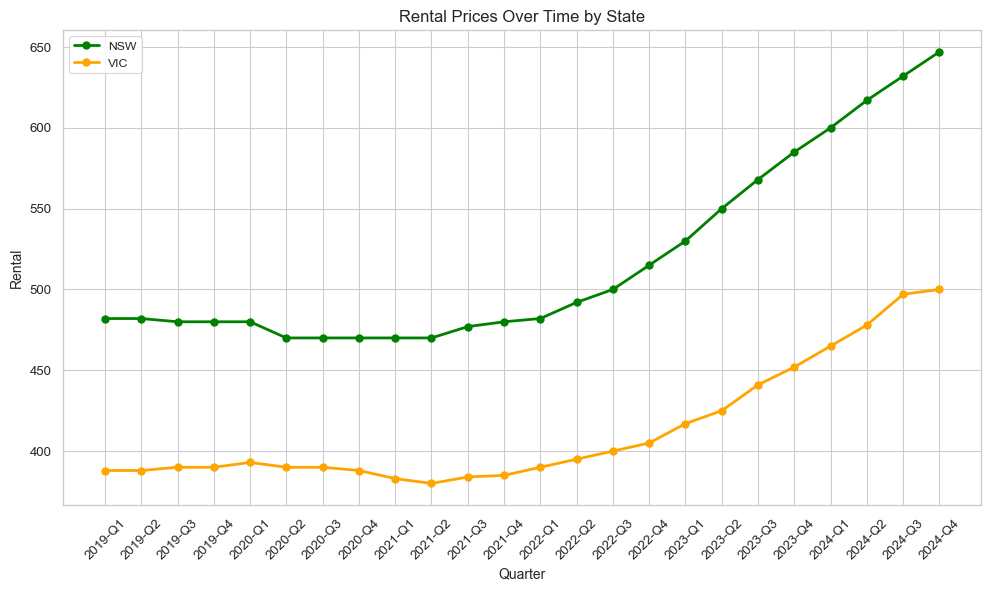

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.0)

plt.figure(figsize=(10, 6))

palette = {"NSW": "green", "VIC": "orange"}

for state in df["State"].unique():
    temp = df[df["State"] == state]
    plt.plot(
        temp["Date"].astype(str),
        temp["Rental"],
        marker="o",
        linewidth=2,
        markersize=5,
        label=state,
        color=palette.get(state)
    )

plt.xticks(rotation=45, fontsize=9.5)
plt.yticks(fontsize=9.5)
plt.title("Rental Prices Over Time by State", fontsize=12)
plt.xlabel("Quarter", fontsize=10)
plt.ylabel("Rental", fontsize=10)
plt.legend(title=None)
plt.tight_layout()
plt.savefig(output_dir / "01_rental_trend.png", dpi=300, bbox_inches="tight")
plt.show()

Rental prices exhibit a clear upward trend over time in both New South Wales (NSW) and Victoria (VIC). While prices remain relatively stable between 2019 and early 2021, a noticeable increase occurs from 2022 onwards, with a sharper rise observed in NSW compared to VIC. This pattern is consistent with increased housing demand placing upward pressure on rental prices. NSW consistently maintains higher rental prices than VIC throughout the entire period despite both states follow a broadly similar trend, indicating comparable housing market dynamics. However, as both series exhibit strong time trends, the observed pattern may reflect common macroeconomic factors rather than a causal effect, which will need to be examined in further analysis.

## 3.2 International Students Over Time

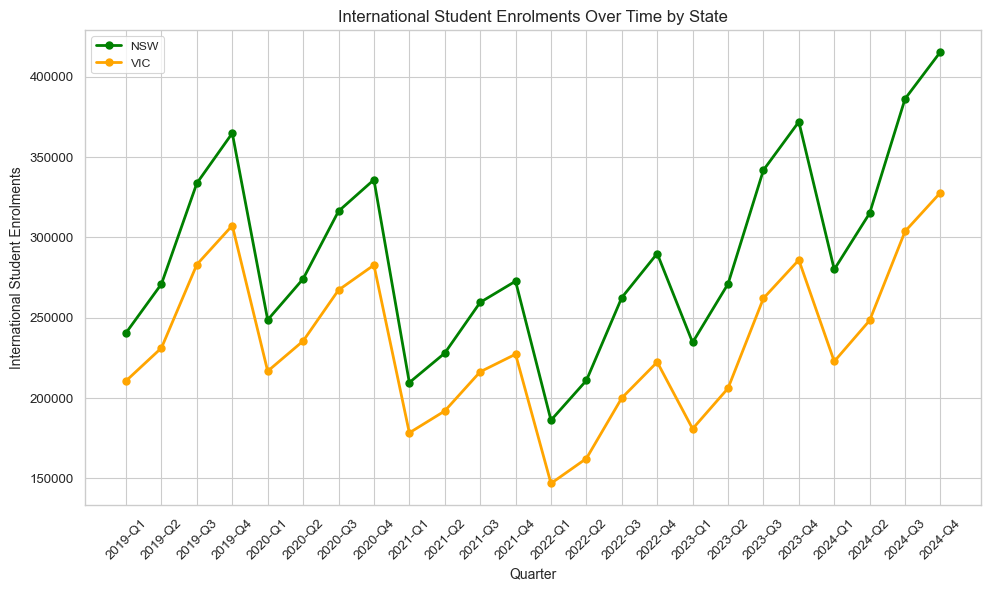

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.0)

plt.figure(figsize=(10, 6))

palette = {"NSW": "green", "VIC": "orange"}

for state in df["State"].unique():
    temp = df[df["State"] == state]
    plt.plot(
        temp["Date"].astype(str),
        temp["International Student Enrolments"],
        marker="o",
        linewidth=2,
        markersize=5,
        label=state,
        color=palette.get(state)
    )

plt.xticks(rotation=45, fontsize=9.5)
plt.yticks(fontsize=9.5)
plt.title("International Student Enrolments Over Time by State", fontsize=12)
plt.xlabel("Quarter", fontsize=10)
plt.ylabel("International Student Enrolments", fontsize=10)
plt.legend(title=None)
plt.tight_layout()
plt.savefig(output_dir / "02_student_trend.png", dpi=300, bbox_inches="tight")
plt.show()

International student enrolments display an overall upward trend over time in both New South Wales (NSW) and Victoria (VIC), with NSW consistently recording higher enrolment levels. However, the data also exhibits a strong seasonal pattern, with enrolments increasing within each year before resetting at the start of the following year. This pattern reflects the year-to-date (YTD) nature of the data, where enrolments accumulate over the course of each year rather than representing new inflows at a specific point in time. As a result, the upward movements observed within each year are partly mechanical and do not necessarily indicate continuous growth in student arrivals. Despite this, there appears to be a general increase in enrolment levels across years, particularly after 2022, which may reflect a recovery in international student demand following COVID-19 disruptions. However, the presence of both seasonal and cumulative effects suggests that caution is required when interpreting this variable in relation to rental prices.

## 3.3 Combined Trends

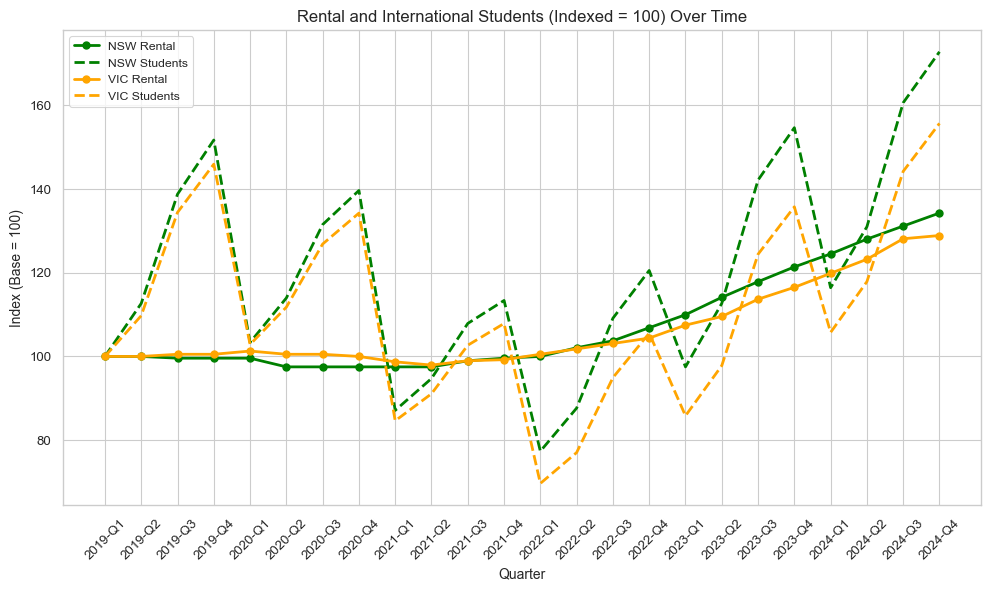

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.0)

plt.figure(figsize=(10, 6))

palette = {"NSW": "green", "VIC": "orange"}

for state in df["State"].unique():
    temp = df[df["State"] == state].copy()
    
    # Normalize both variables (base = first value = 100)
    temp["Rental_norm"] = temp["Rental"] / temp["Rental"].iloc[0] * 100
    temp["Students_norm"] = temp["International Student Enrolments"] / temp["International Student Enrolments"].iloc[0] * 100

    # Plot Rental
    plt.plot(
        temp["Date"].astype(str),
        temp["Rental_norm"],
        marker="o",
        linewidth=2,
        markersize=5,
        label=f"{state} Rental",
        color=palette.get(state)
    )

    # Plot Students (dashed line)
    plt.plot(
        temp["Date"].astype(str),
        temp["Students_norm"],
        linestyle="--",
        linewidth=2,
        label=f"{state} Students",
        color=palette.get(state)
    )

plt.xticks(rotation=45, fontsize=9.5)
plt.yticks(fontsize=9.5)
plt.title("Rental and International Students (Indexed = 100) Over Time", fontsize=12)
plt.xlabel("Quarter", fontsize=10)
plt.ylabel("Index (Base = 100)", fontsize=10)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "03_combined_trend.png", dpi=300, bbox_inches="tight")
plt.show()

The plot provides a clear comparison of the relative movements in rental prices and international student enrolments over time across both New South Wales (NSW) and Victoria (VIC). Rental prices in both states follow a relatively smooth and gradual upward trend, particularly from 2022 onwards, indicating a sustained increase in housing costs. This pattern is consistent with economic intuition, where rising demand for housing, potentially driven by population growth and returning migration, places upward pressure on rental prices. In contrast, the short-term fluctuations in enrolments of international student do not necessarily represent true changes in student inflows, but rather the structure of the data itself. Despite these differences, both rental prices and enrolments exhibit a general upward trend over the later period, particularly after 2022, which may reflect the recovery of international mobility and economic activity following COVID-19 disruptions. However, the divergence in smoothness between the two series suggests that rental markets adjust more gradually, while enrolment data captures short-term accumulation effects. The presence of strong time trends in both variables raises concerns about spurious correlation, where two variables appear related simply because they are trending over time. Additionally, the measurement of enrolments as a cumulative variable introduces potential bias, as it does not directly capture the flow of new students entering the housing market. Therefore, while the visual evidence suggests a possible positive association, it is insufficient to establish a causal relationship, and further analysis controlling for time effects and other confounding variables is required.

# 4. Relationship Among Variables

## 4.1 Rental VS International Student 

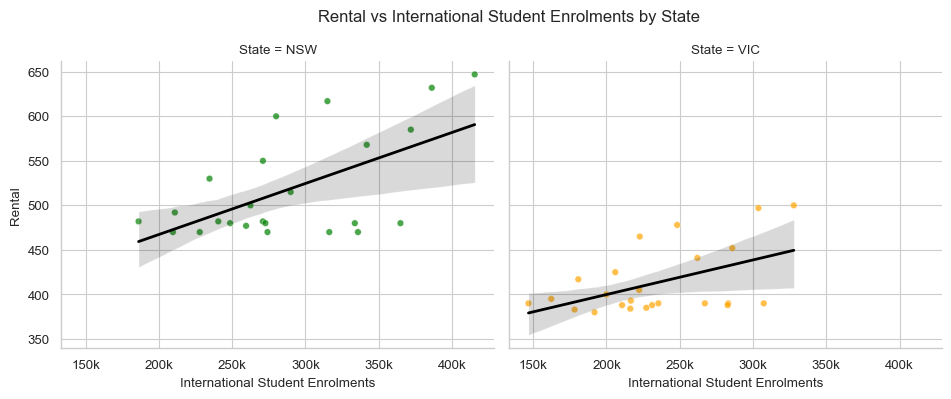

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.0)

g = sns.relplot(
    data=df,
    x="International Student Enrolments",
    y="Rental",
    col="State",
    hue="State",
    palette={"NSW": "green", "VIC": "orange"},
    kind="scatter",
    height=4,
    aspect=1.2,
    alpha=0.7
)

# Add trendline to each state panel
for ax, state in zip(g.axes.flat, sorted(df["State"].unique())):
    sns.regplot(
        data=df[df["State"] == state],
        x="International Student Enrolments",
        y="Rental",
        scatter=False,
        ax=ax,
        color="black",
        line_kws={"linewidth": 2}
    )

g._legend.remove()
g.set_axis_labels("International Student Enrolments", "Rental")

formatter = FuncFormatter(lambda x, pos: f"{int(x/1000)}k")
for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(formatter)
    ax.tick_params(axis="both", labelsize=9.5)

g.fig.suptitle("Rental vs International Student Enrolments by State", fontsize=12)
g.fig.subplots_adjust(top=0.85)

plt.savefig(output_dir / "04_rental_vs_student.png", dpi=300, bbox_inches="tight")
plt.show()

The scatterplots for both NSW and Victoria show a positive relationship between international student enrolments and rental prices. As enrolments increase, rental prices tend to rise, as indicated by the upward-sloping fitted regression lines in both states. This pattern is economically intuitive. An increase in international students raises demand for rental housing, particularly in major cities such as Sydney and Melbourne, where most students are concentrated. Given that housing supply is relatively inelastic in the short run, higher demand puts upward pressure on rental prices. Comparing the two states, the relationship appears stronger and more pronounced in NSW, where both the slope of the trend line and the spread of rental prices are higher. This suggests that rental markets in NSW may be more sensitive to changes in student demand, possibly due to tighter housing supply or higher baseline demand. However, it is important to note that this relationship reflects correlation, not causation. Other factors—such as population growth, housing supply constraints, income levels, and broader economic conditions—may also influence rental prices. Therefore, without controlling for these variables in a regression framework, the observed relationship may be subject to omitted variable bias.

## 4.2 Rental VS Housing Supply 

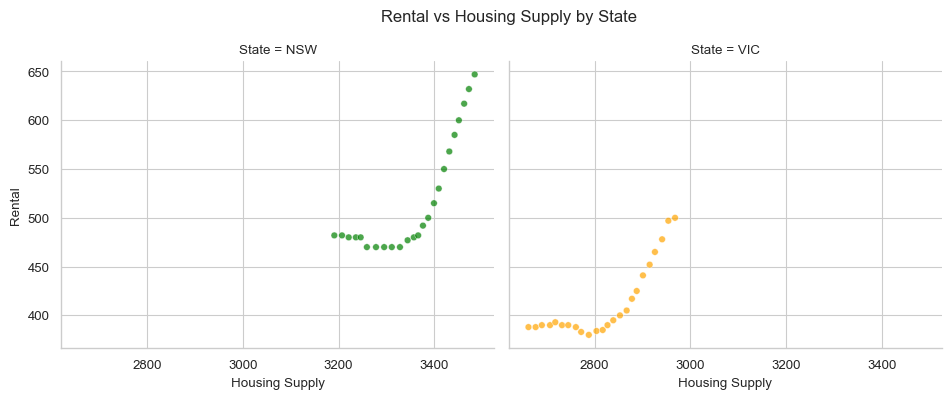

In [29]:
g = sns.relplot(
    data=df,
    x="Housing Supply",
    y="Rental",
    col="State",
    hue="State",
    palette={"NSW": "green", "VIC": "orange"},
    height=4,
    aspect=1.2,
    alpha=0.7
)

g._legend.remove()

for ax in g.axes.flat:
    ax.tick_params(axis="both", labelsize=9.5)

g.fig.suptitle("Rental vs Housing Supply by State", fontsize=12)
g.fig.subplots_adjust(top=0.85)

plt.savefig(output_dir / "05_rental_vs_housing.png", dpi=300, bbox_inches="tight")
plt.show()

The scatterplot shows a positive association between housing supply and rental prices in both New South Wales and Victoria, where rental prices tend to increase as the number of dwellings rises. While this appears counterintuitive relative to standard economic theory, the pattern can be better understood in the context of the time period (2019–2024) and the structure of the data. Over this period, both housing supply and rental prices exhibit a clear upward trend. Housing supply, measured as the total number of residential dwellings, increases steadily over time due to ongoing construction and accumulation of housing stock. At the same time, rental prices—particularly after 2021—rise sharply, likely reflecting post-pandemic demand recovery, the return of international students, and broader population growth. As a result, the positive relationship observed in the scatterplot may largely reflect a common time trend, where both variables are increasing over the same period rather than indicating a direct causal relationship. In addition, housing supply in this dataset is measured at the state level (NSW and VIC), which aggregates across highly heterogeneous housing markets. Within each state, new housing developments are more likely to occur in high-demand areas—such as Sydney and Melbourne, particularly in suburbs close to universities and employment centres. These are also the areas where rental prices are highest and rising most rapidly. Consequently, increases in housing supply are likely occurring in locations that already experience strong rental demand, leading to a positive association in the aggregated data. This reflects aggregation bias, where the state-level relationship does not capture the underlying suburb-level dynamics. From an econometric perspective, the observed pattern is also likely influenced by omitted variable bias. Key demand-side factors in your dataset—such as international student enrolments, population growth, and possibly GDP—are not accounted for in this bivariate relationship. These factors are particularly important in your context, as international student enrolments declined during COVID-19 and rebounded strongly afterwards, which likely contributed to the sharp increase in rental prices. Since these variables are correlated with both housing supply and rental prices, failing to control for them may bias the observed relationship upward. Furthermore, housing supply is unlikely to be exogenous. Developers tend to respond to expected profitability, meaning that higher or rising rental prices may incentivise more construction. This introduces reverse causality, where rental prices influence housing supply rather than the other way around. Overall, the positive association between housing supply and rental prices in this dataset should not be interpreted as evidence that increasing supply leads to higher rents. Instead, it reflects the interaction of strong demand recovery (particularly post-2021), common upward trends in both variables, and the aggregation of heterogeneous housing markets within each state. A more reliable assessment of the effect of housing supply on rental prices would require controlling for demand-side variables and isolating variation in supply that is independent of these broader market forces.

## 4.3 Rental VS Population 

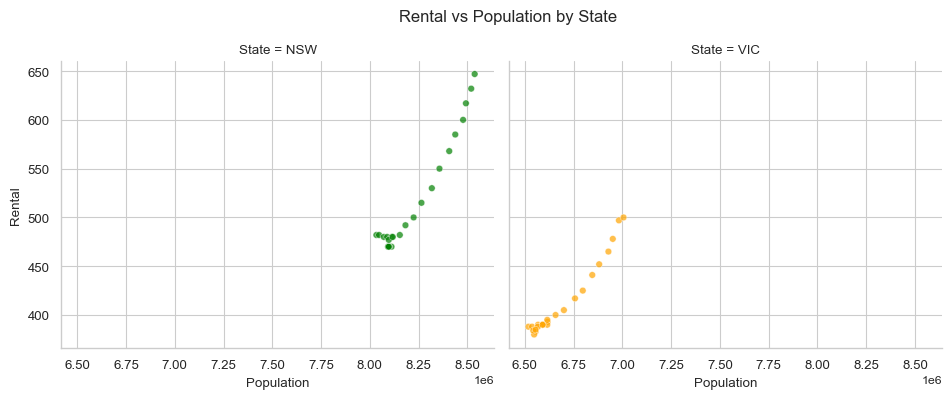

In [30]:
g = sns.relplot(
    data=df,
    x="Population",
    y="Rental",
    col="State",
    hue="State",
    palette={"NSW": "green", "VIC": "orange"},
    height=4,
    aspect=1.2,
    alpha=0.7
)

g._legend.remove()

for ax in g.axes.flat:
    ax.tick_params(axis="both", labelsize=9.5)

g.fig.suptitle("Rental vs Population by State", fontsize=12)
g.fig.subplots_adjust(top=0.85)

plt.savefig(output_dir / "06_rental_vs_population.png", dpi=300, bbox_inches="tight")
plt.show()

The scatterplot shows a clear positive relationship between population and rental prices in both NSW and Victoria, with higher population levels associated with higher rents. Unlike the housing supply graph, this pattern is broadly consistent with textbook economic theory, since population growth increases demand for housing and can place upward pressure on rents when supply does not expand at the same pace. In the context of this study, the relationship is plausible given the 2019–2024 period, during which both states experienced population recovery alongside rising rental prices, particularly after the reopening of borders and the return of migration and international students. However, the graph should still be interpreted cautiously. Because both population and rental prices trend upward over time, the observed association may partly reflect a common time trend rather than a clean causal effect. In addition, population is measured at the state level and does not capture where growth occurs within each state, so important local housing pressures may be hidden by aggregation. The relationship may also be influenced by omitted demand-side factors, including international student enrolments and broader economic conditions. Therefore, while the graph supports the idea that stronger population growth is associated with higher rental demand and higher rents, it does not by itself identify the independent causal effect of population on rental prices.